In [9]:
#Loading in Data

import pandas as pd

df = pd.read_csv("../data/PRE_PCA.csv")

df.head()

,match_id,game_length,puuid,gold_left,last_round,players_eliminated,time_eliminated,total_damage_to_players,placement
0,NA1_5214474372,2240.723633,VKwva7riXrRpNn_pQCF7Gx63CYKG4PxcbND2JnL3Tcceb6...,40,28,1,1676.477051,61,5
1,NA1_5214474372,2240.723633,CSZABWFZly3iWPGGobYZhYk9knB5J0-pUQbO02Zx85ShQv...,0,21,0,1216.563843,15,8
2,NA1_5214474372,2240.723633,B_mWPVRiuzGR-eUTN6CDIwkjbf_PXOmitrSgK3r-Yo38gK...,4,27,0,1608.733765,47,6
3,NA1_5214474372,2240.723633,_W30FKv18DHc61O6J_7rVUV5nrp779aWIE3MSuA0YS9Mcu...,0,33,1,1934.663574,94,4
4,NA1_5214474372,2240.723633,-rQ5Ep_GYZG2QjV9oB3GnGS494CbFg7oZWjGYLBKMW9efl...,1,26,0,1548.258301,46,7


In [10]:
#Dropping Qualitative Columns and Labels
df_new = df.drop(['match_id', 'puuid', 'placement'], axis=1)

df_new.head()

,game_length,gold_left,last_round,players_eliminated,time_eliminated,total_damage_to_players
0,2240.723633,40,28,1,1676.477051,61
1,2240.723633,0,21,0,1216.563843,15
2,2240.723633,4,27,0,1608.733765,47
3,2240.723633,0,33,1,1934.663574,94
4,2240.723633,1,26,0,1548.258301,46


In [3]:
#Output to CSV
df_new.to_csv("../data/PCA.csv", index=False)


PermissionError: [Errno 13] Permission denied: '../data/PCA.csv'

In [11]:
#Normalization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_scaled_array = scaler.fit_transform(df_new)

df_scaled = pd.DataFrame(df_scaled_array, columns=df_new.columns)

df_scaled.head()


,game_length,gold_left,last_round,players_eliminated,time_eliminated,total_damage_to_players
0,0.701756,2.308218,-0.884969,0.173684,-0.719364,-0.813224
1,0.701756,-0.542417,-2.437015,-0.736637,-2.534173,-1.767466
2,0.701756,-0.257353,-1.106690,-0.736637,-0.986677,-1.103646
3,0.701756,-0.542417,0.223634,0.173684,0.299436,-0.128659
4,0.701756,-0.471151,-1.328411,-0.736637,-1.225313,-1.124390


In [12]:
#PCA
from sklearn.decomposition import PCA

# --- PCA with n_components=2 ---
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(df_scaled)
df_pca_2 = pd.DataFrame(X_pca_2, columns=['PC1', 'PC2'])

print("Explained variance ratio (2 components):", pca_2.explained_variance_ratio_)

# --- PCA with n_components=3 ---
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(df_scaled)
df_pca_3 = pd.DataFrame(X_pca_3, columns=['PC1', 'PC2', 'PC3'])

print("Explained variance ratio (3 components):", pca_3.explained_variance_ratio_)

print("\nFirst 5 rows of 2-component PCA:")
print(df_pca_2.head())

print("\nFirst 5 rows of 3-component PCA:")
print(df_pca_3.head())


Explained variance ratio (2 components): [0.57440089 0.17612735]
Explained variance ratio (3 components): [0.57440089 0.17612735 0.15827005]

First 5 rows of 2-component PCA:
        PC1       PC2
0 -1.100680  1.206206
1 -3.756480 -0.862198
2 -1.916289 -0.754307
3  0.336231 -0.875288
4 -2.167720 -0.884619

First 5 rows of 3-component PCA:
        PC1       PC2       PC3
0 -1.100680  1.206206  2.171129
1 -3.756480 -0.862198  0.323565
2 -1.916289 -0.754307  0.458250
3  0.336231 -0.875288  0.122220
4 -2.167720 -0.884619  0.313677


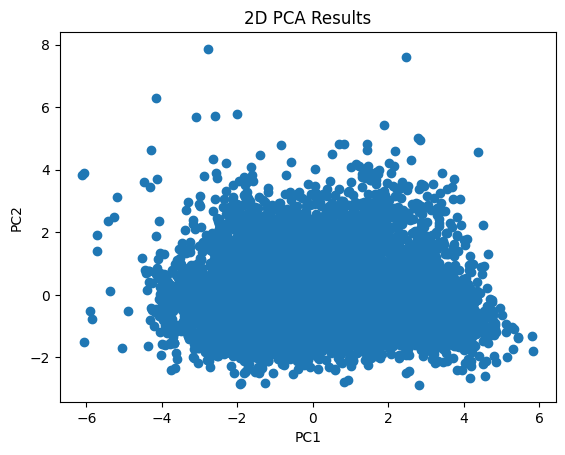

In [13]:
#2D Visualization
import matplotlib.pyplot as plt

plt.scatter(df_pca_2['PC1'], df_pca_2['PC2'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('2D PCA Results')
plt.show()

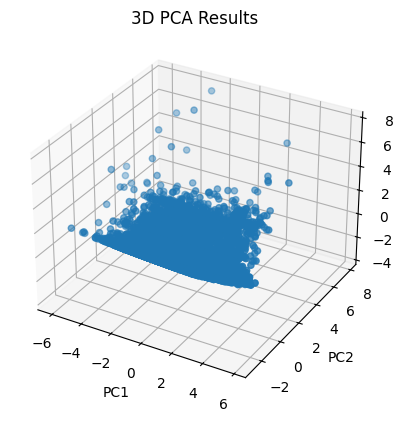

In [14]:
#3D Visualization
from mpl_toolkits.mplot3d import Axes3D  

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df_pca_3['PC1'], df_pca_3['PC2'], df_pca_3['PC3'])

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.title('3D PCA Results')

plt.show()

In [16]:
#Cumulative Explained Variance
import numpy as np

# --- PCA with n_components=2 ---
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(df_scaled)
df_pca_2 = pd.DataFrame(X_pca_2, columns=['PC1', 'PC2'])

print("Explained variance ratio (2 components):", pca_2.explained_variance_ratio_)

explained_variance_ratios_2 = pca_2.explained_variance_ratio_
cumulative_variance_2 = np.cumsum(explained_variance_ratios_2)
print("Cumulative explained variance (2 components) in %:")
for i, cv in enumerate(cumulative_variance_2, start=1):
    print(f"Up to PC{i}: {cv*100:.2f}%")

# --- PCA with n_components=3 ---
pca_3 = PCA(n_components=3)
X_pca_3 = pca_3.fit_transform(df_scaled)
df_pca_3 = pd.DataFrame(X_pca_3, columns=['PC1', 'PC2', 'PC3'])

print("\nExplained variance ratio (3 components):", pca_3.explained_variance_ratio_)

explained_variance_ratios_3 = pca_3.explained_variance_ratio_
cumulative_variance_3 = np.cumsum(explained_variance_ratios_3)
print("Cumulative explained variance (3 components) in %:")
for i, cv in enumerate(cumulative_variance_3, start=1):
    print(f"Up to PC{i}: {cv*100:.2f}%")

print("\nFirst 5 rows of 2-component PCA:")
print(df_pca_2.head())

print("\nFirst 5 rows of 3-component PCA:")
print(df_pca_3.head())

Explained variance ratio (2 components): [0.57440089 0.17612735]
Cumulative explained variance (2 components) in %:
Up to PC1: 57.44%
Up to PC2: 75.05%

Explained variance ratio (3 components): [0.57440089 0.17612735 0.15827005]
Cumulative explained variance (3 components) in %:
Up to PC1: 57.44%
Up to PC2: 75.05%
Up to PC3: 90.88%

First 5 rows of 2-component PCA:
        PC1       PC2
0 -1.100680  1.206206
1 -3.756480 -0.862198
2 -1.916289 -0.754307
3  0.336231 -0.875288
4 -2.167720 -0.884619

First 5 rows of 3-component PCA:
        PC1       PC2       PC3
0 -1.100680  1.206206  2.171129
1 -3.756480 -0.862198  0.323565
2 -1.916289 -0.754307  0.458250
3  0.336231 -0.875288  0.122220
4 -2.167720 -0.884619  0.313677
